# Aprendizaje de Máquina - Laboratorio 3

## Integrantes

| Nombre             | Código    | Correo electrónico           |
|--------------------|-----------|------------------------------|
| Adrian Velasquez   | 202222737 | a.velasquezs@uniandes.edu.co |
| Andres Botero Ruiz | 202223503 | a.boteror@uniandes.edu.co    |

# Preparación del entorno de trabajo y carga de datos

In [453]:
# Definición de constantes

DATA_PATH = './data/'
DATA_FILE = DATA_PATH + 'data.csv'
TEST_FILE = DATA_PATH + 'test.csv'

In [454]:
# Importar librerias

import re
import unicodedata

# Data + graphics
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Scikit-learn
from sklearn import set_config
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Lasso, Ridge, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, classification_report, confusion_matrix, \
    ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, FunctionTransformer, StandardScaler, MinMaxScaler, OneHotEncoder, \
    RobustScaler, Normalizer, MaxAbsScaler
from sklearn.utils import resample
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

In [455]:
# Cargar los datos
data = pd.read_csv(DATA_FILE, encoding='iso-8859-1', delimiter=';')
df = data.copy()
df.head()

,Edad,Gnereo,Peso,Altura,BMI,Objetivo,Condicion_salud,Nivel_Actividad,Nivel_experiencia,Dieta_preferida,...,Fumador,Cigarrillos_dia,Alcohol,Alcohol_semana,Score_micronutrientes,Ingesta_proteinas,Pasos_dia,Ingesta_agua,Plan_entrenamiento,Plan_nutrición
0,60,Masculino,73.7,1.61,28.43,Resistencia,Hipertension,Bajo,Avanzado,Vegano,...,0,0.0,0,0.0,0.92,182.1,16485,2.49,Medio,Sin plan
1,17,Femenino,121.0,1.97,31.18,Resistencia,Enfermedad corazon,Moderado,Principiante,Vegetariano,...,0,0.0,0,0.0,0.76,167.7,14256,2.04,Ninguno,Sin plan
2,43,Masculino,110.0,1.52,47.61,General,Ninguno,Bajo,Principiante,No-Vegetariano,...,0,0.0,0,0.0,0.34,104.9,3050,2.53,Bajo,Basico
3,49,Otro,73.6,1.96,19.16,General,Ninguno,Moderado,Principiante,No-Vegetariano,...,0,0.0,0,0.0,0.71,59.5,2264,3.36,Ninguno,Sin plan
4,53,Femenino,80.8,1.76,26.08,Resistencia,Hipertension,Alto,Principiante,Pescetariano,...,1,8.7,0,0.0,0.98,51.1,12774,1.90,Medio,Sin plan


In [456]:
# Crear un FunctionTransformer para limpiar nombres de las columnas (añadir al pipeline)
def clean_column_names(t_df):
    t_df = t_df.copy()
    if 'Gnereo' in t_df.columns:
        t_df['Genero'] = t_df['Gnereo']  # Corregir el typo
        t_df = t_df.drop(columns=['Gnereo'])
    new_cols = []
    for col in t_df.columns:
        col = str(col)
        # quitar tildes/acentos
        col = unicodedata.normalize("NFKD", col).encode("ascii", "ignore").decode("ascii")
        # normalizar formato
        col = col.strip().lower()
        col = re.sub(r"\s+", "_", col)  # espacios -> _
        col = re.sub(r"[^a-z0-9_]", "", col)  # borrar caracteres raros
        new_cols.append(col)

    t_df.columns = new_cols
    return t_df


ft_name_cleaner = FunctionTransformer(clean_column_names, validate=False)

In [457]:
# Limpiar nombres de las columnas
df = ft_name_cleaner.transform(df)
df.sample(5)

,edad,peso,altura,bmi,objetivo,condicion_salud,nivel_actividad,nivel_experiencia,dieta_preferida,horas_sueno,...,cigarrillos_dia,alcohol,alcohol_semana,score_micronutrientes,ingesta_proteinas,pasos_dia,ingesta_agua,plan_entrenamiento,plan_nutricion,genero
689,56,56.5,1.57,22.92,Resistencia,Ninguno,Moderado,Intermedio,Vegetariano,6.3,...,0.0,0,0.0,0.13,135.9,16201,4.40,Ninguno,Sin plan,Femenino
2516,48,137.2,1.85,40.09,Resistencia,Hipertension,Moderado,Intermedio,Vegetariano,5.2,...,0.0,1,11.4,0.11,88.1,8470,1.97,Bajo,Balanceado,Masculino
1364,53,82.1,2.03,19.92,Ganancia muscular,Hipertension,Moderado,Intermedio,Vegano,9.1,...,0.0,1,4.1,0.71,152.1,12778,3.40,Bajo,Balanceado,Femenino
7943,64,88.6,1.68,31.39,General,Diabetes,Bajo,Avanzado,Vegetariano,7.6,...,11.7,1,23.1,0.05,192.9,4687,3.26,Bajo,Balanceado,Masculino
3594,15,58.5,1.76,18.89,General,Ninguno,Bajo,Principiante,Pescetariano,6.7,...,0.0,0,0.0,0.83,215.9,16325,3.60,Ninguno,Sin plan,Masculino


In [458]:
# Definición de las variables objetivo (son 2 de acuerdo al negocio)
VOE = 'plan_entrenamiento'
VON = 'plan_nutricion'

In [459]:
# Separación de variables numéricas y categóricas
numerical_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(include=['object', 'string']).columns

# Análisis exploratorio y calidad de datos

In [460]:
# Información general del dataset
print(f"Cantidad de filas: {len(df)}")
print(f"Cantidad de columnas: {len(df.columns)}")
print("\nTipos de datos:")
df.info()

Cantidad de filas: 9698
Cantidad de columnas: 26

Tipos de datos:
<class 'pandas.DataFrame'>
RangeIndex: 9698 entries, 0 to 9697
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   edad                     9698 non-null   int64  
 1   peso                     9687 non-null   float64
 2   altura                   9698 non-null   float64
 3   bmi                      9698 non-null   float64
 4   objetivo                 9698 non-null   str    
 5   condicion_salud          9698 non-null   str    
 6   nivel_actividad          9698 non-null   str    
 7   nivel_experiencia        9698 non-null   str    
 8   dieta_preferida          9698 non-null   str    
 9   horas_sueno              9698 non-null   float64
 10  entrenamiento_preferido  9698 non-null   str    
 11  cantidad_equipo          9698 non-null   int64  
 12  tiempo_disponible        9698 non-null   int64  
 13  tiene_alergia          

Solo hay 1 nulo en la columna de peso, de resto hay completitud en los datos

In [461]:
# Descripción de variables numéricas
df.describe()

,edad,peso,altura,bmi,horas_sueno,cantidad_equipo,tiempo_disponible,tiene_alergia,problemas_digestivos,fumador,cigarrillos_dia,alcohol,alcohol_semana,score_micronutrientes,ingesta_proteinas,pasos_dia,ingesta_agua
count,9698.000000,9687.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000
mean,45.112601,92.622515,1.775047,30.131391,7.004382,2.988039,67.194061,0.201588,0.153846,0.227366,2.172252,0.285317,3.778841,0.500115,129.997360,9765.936482,2.748532
std,17.641045,27.383913,0.158754,10.605675,1.449454,2.018493,30.839475,0.401207,0.360820,0.419153,4.624756,0.451588,7.023263,0.289062,51.981874,4762.152079,1.015342
min,15.000000,45.000000,1.500000,10.930000,0.000000,0.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,40.000000,200.000000,1.000000
25%,30.000000,68.800000,1.640000,21.620000,5.800000,1.000000,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.250000,85.000000,5608.250000,1.860000
50%,45.000000,92.600000,1.780000,29.190000,7.000000,3.000000,67.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,129.950000,9718.000000,2.760000
75%,61.000000,116.500000,1.910000,37.060000,8.200000,5.000000,94.000000,0.000000,0.000000,0.000000,0.000000,1.000000,4.300000,0.750000,175.200000,13953.000000,3.620000
max,75.000000,140.000000,2.050000,62.090000,23.000000,6.000000,120.000000,1.000000,1.000000,1.000000,18.000000,1.000000,25.000000,1.000000,220.000000,17996.000000,4.500000


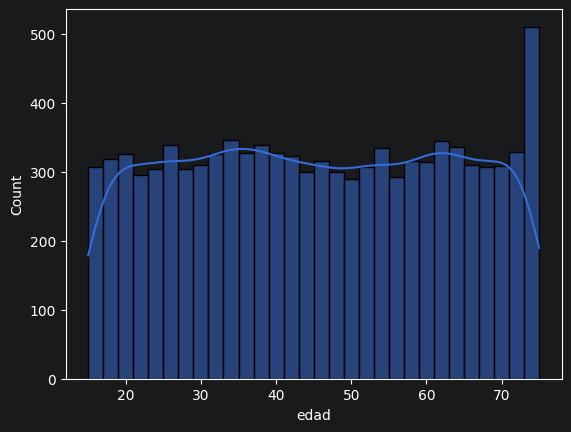

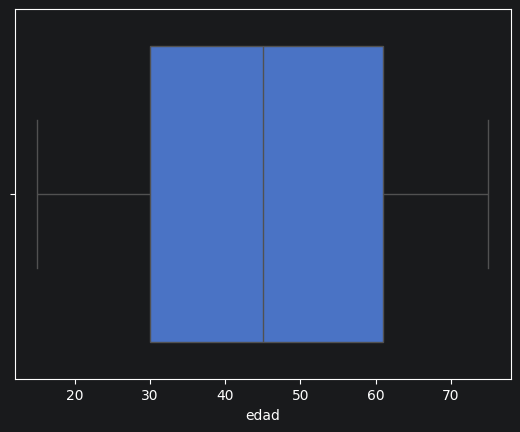

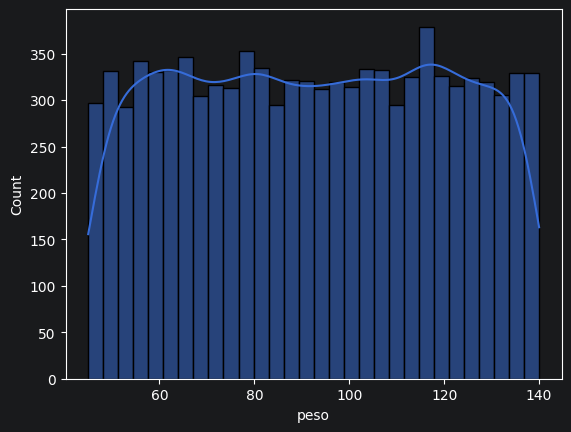

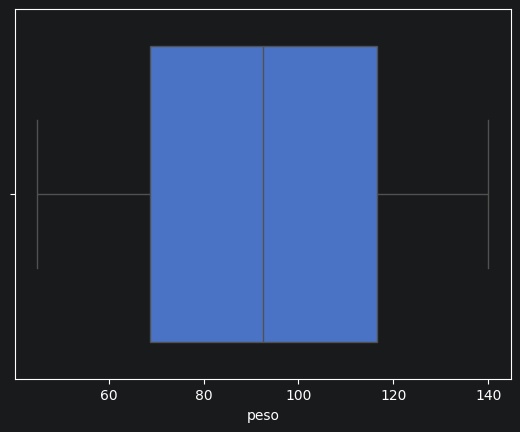

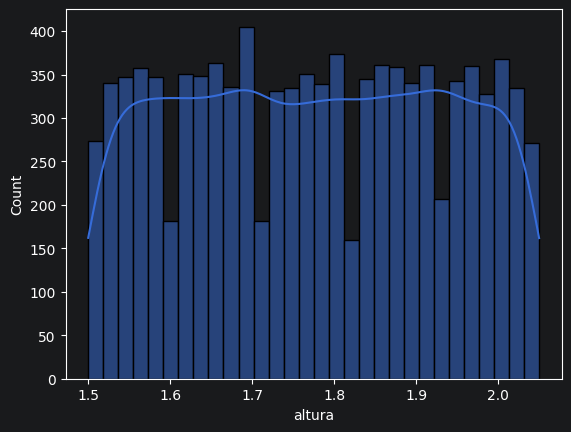

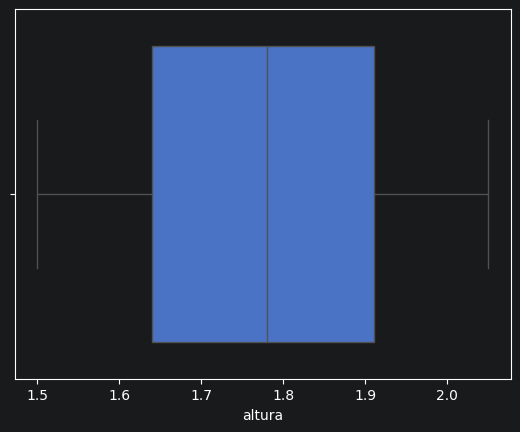

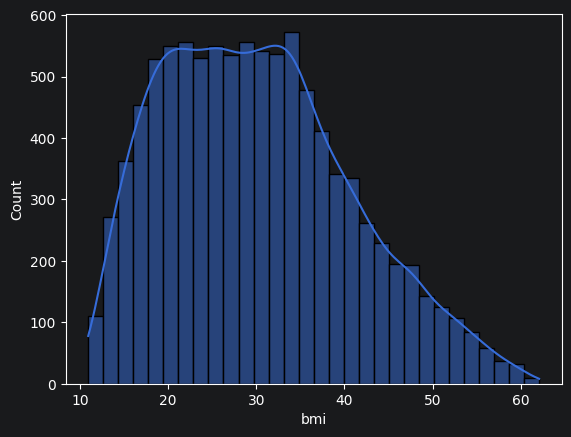

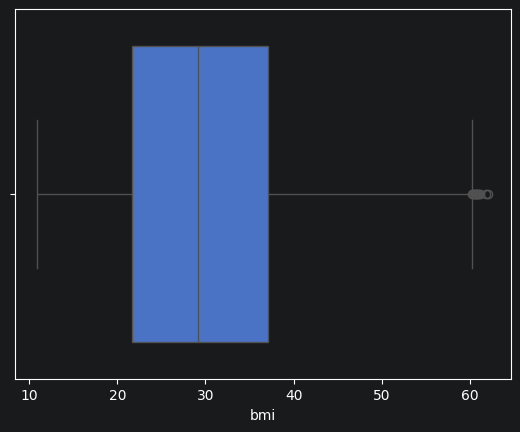

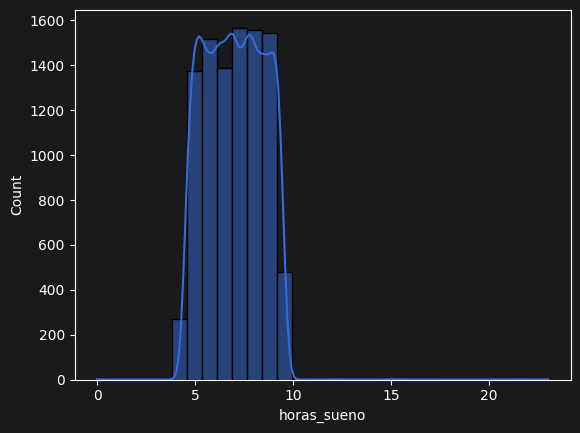

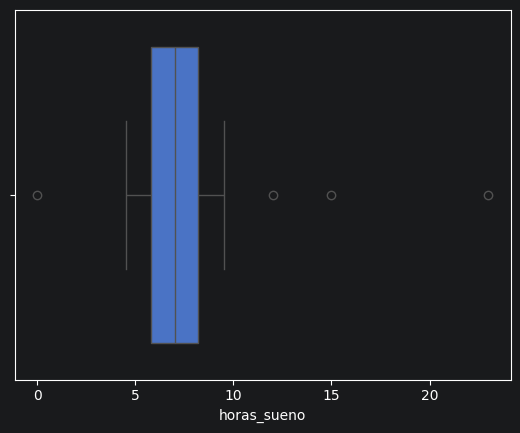

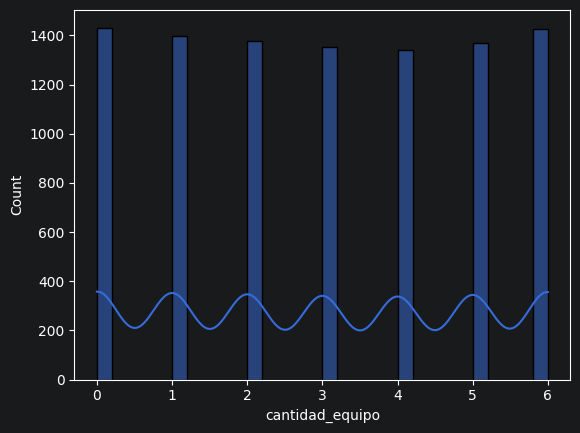

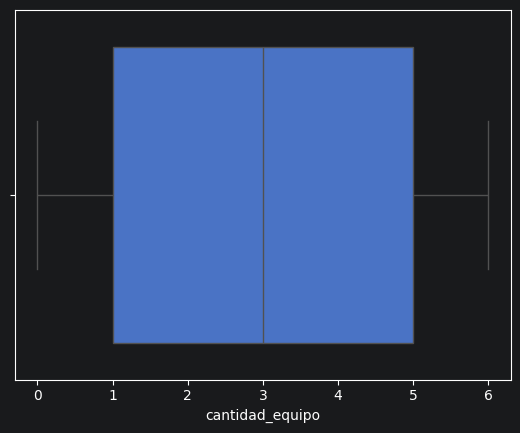

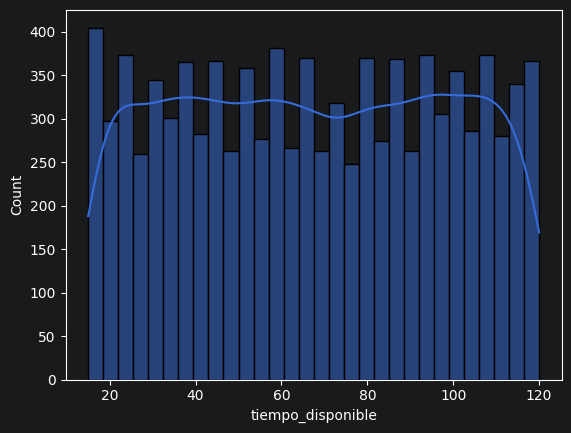

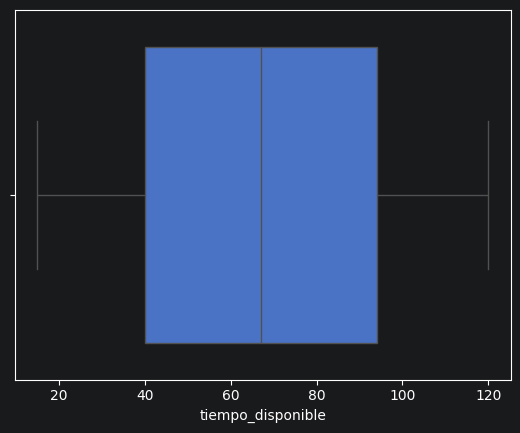

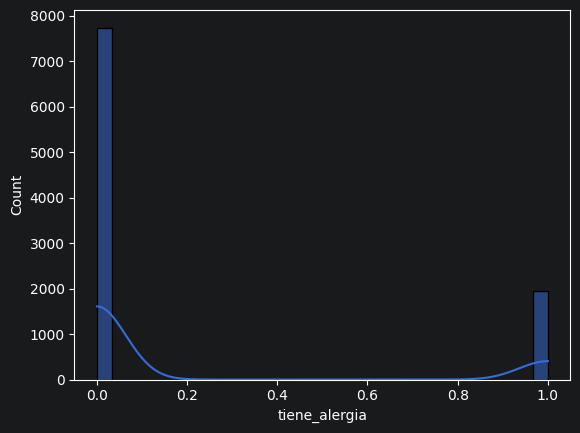

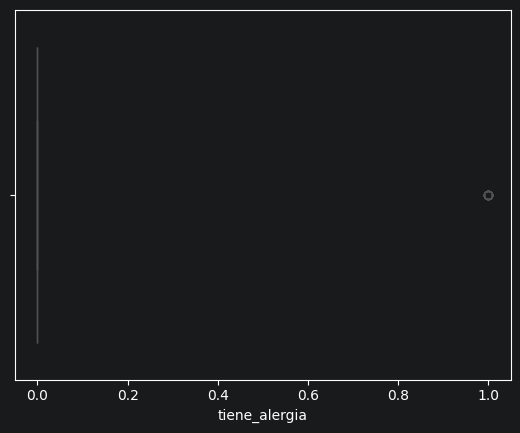

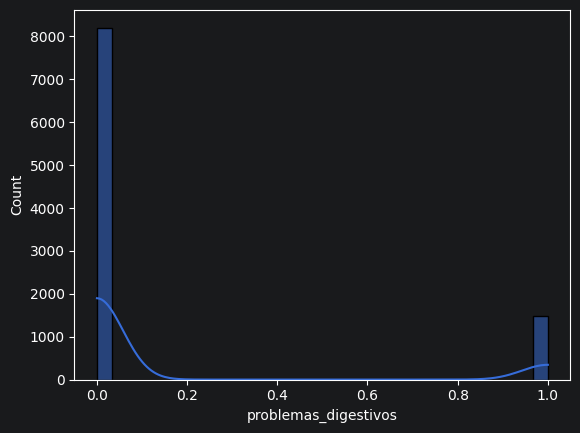

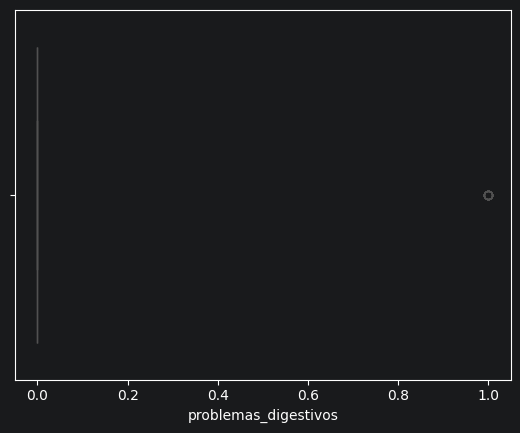

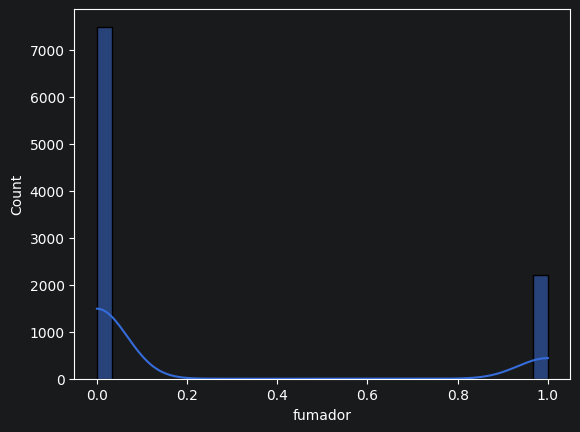

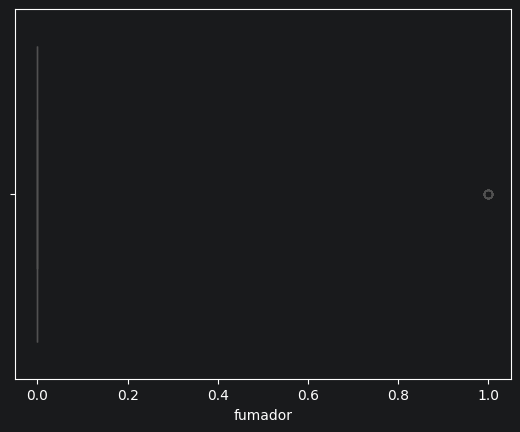

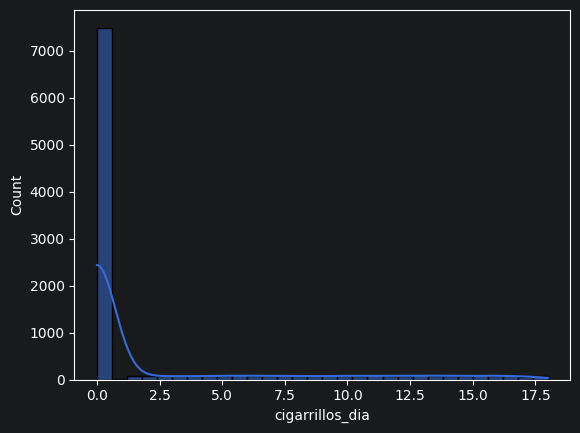

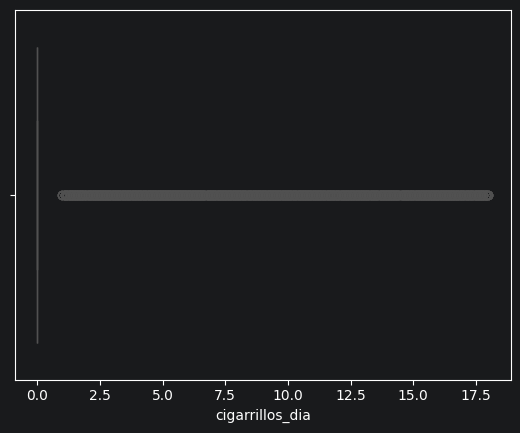

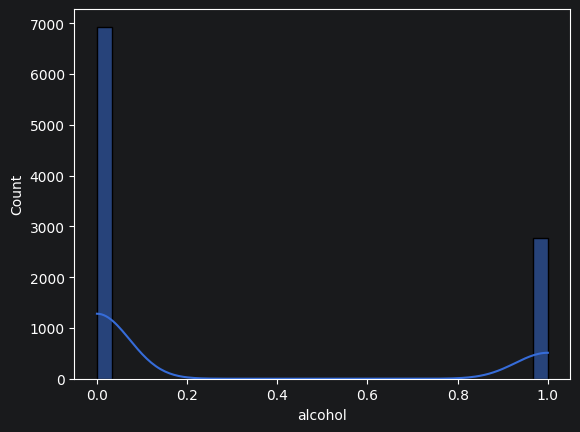

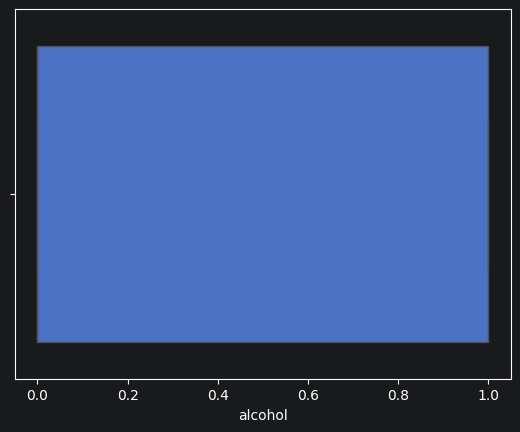

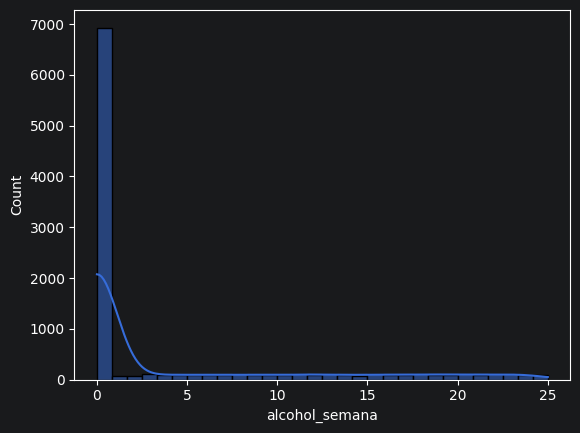

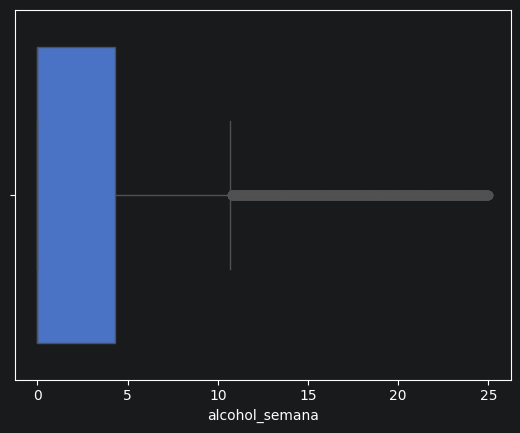

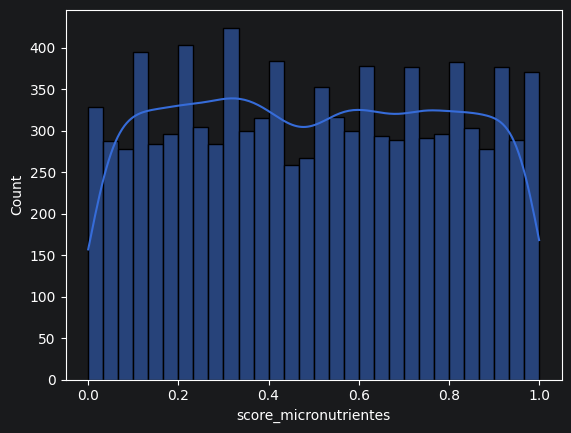

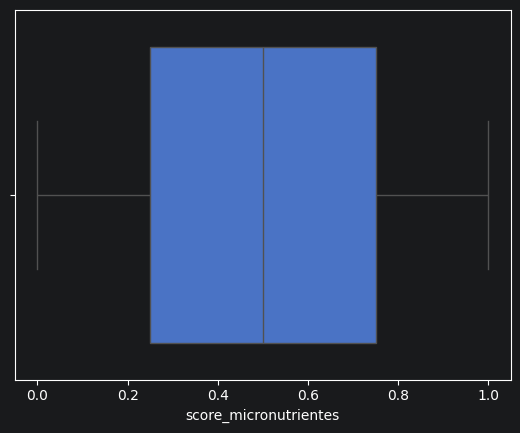

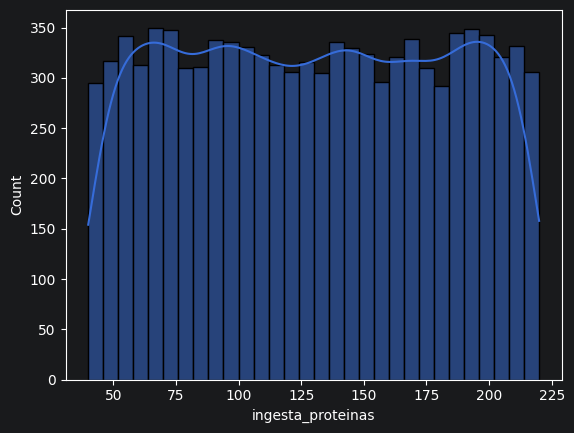

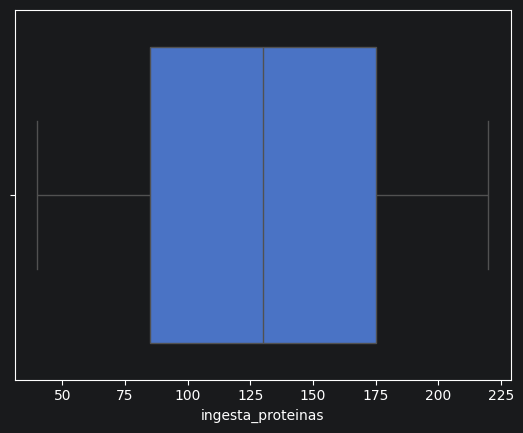

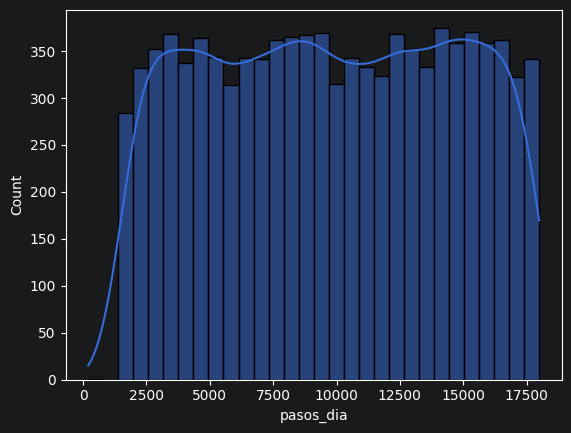

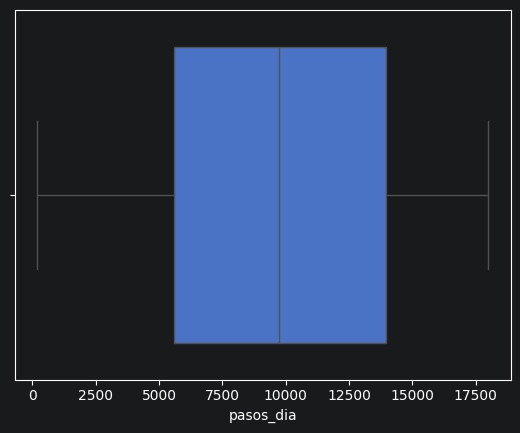

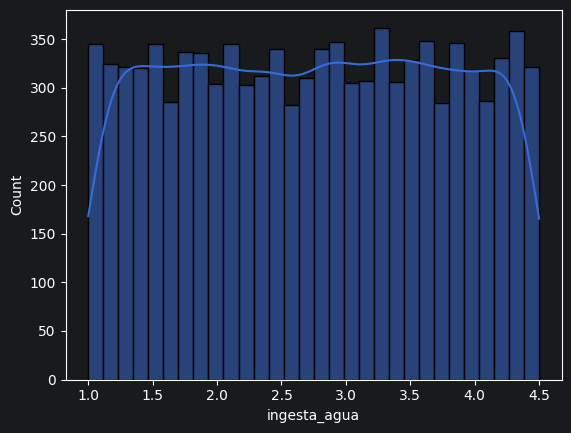

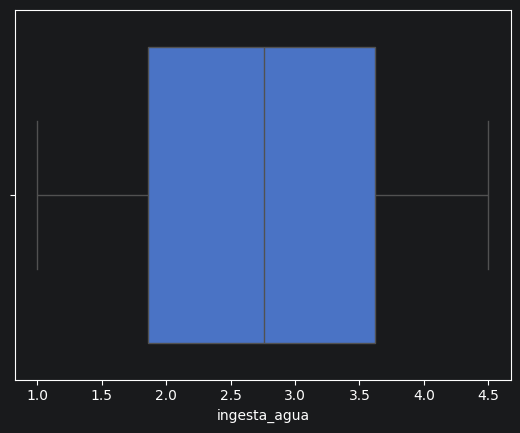

In [462]:
# Gráficas de variables numéricas
for c in numerical_cols:
    sns.histplot(data=df, x=c, kde=True, bins=30)
    plt.show()
    # plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[c])
    plt.show()

En general los datos parecen estar en rangos razonables. Algunas excepciones son:

1. `horas_sueño`: hay al menos un valor de 0 horas de sueño, y al menos un valor de 23 horas de sueño, ambos extremos son poco probables. Esto podría ser un error de registro o casos extremos que podrían considerarse outliers.
2. `tiene_alergia`, `problemas_digestivos`, `fumador`, `alcohol`: Parecen ser variables binarias. Pueden ser consideradas como categóricas, aunque están representadas como numéricas. Se podría considerar convertirlas a variables categóricas para un análisis más adecuado.
3. Con `peso` y `altura` se puede verificar si el `bmi` es consistente, ya que se calcula como $BMI = \frac{peso\ \left(kg\right)}{\left(altura\ \left(m\right)\right)^2}$\. Si hay inconsistencias, podrían ser errores de registro o casos extremos que podrían considerarse outliers\.


Columna: objetivo
objetivo
Ganancia muscular    2757
Perdida grasa        2594
General              2220
Resistencia          2123
grasa                   4
Name: count, dtype: int64


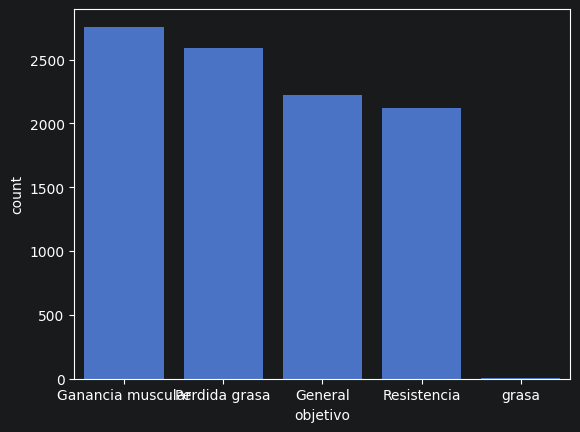


Columna: condicion_salud
condicion_salud
Ninguno               6030
Hipertension           814
Lesion                 764
Asma                   745
Diabetes               511
Enfermedad corazon     497
PCOS                   337
Name: count, dtype: int64


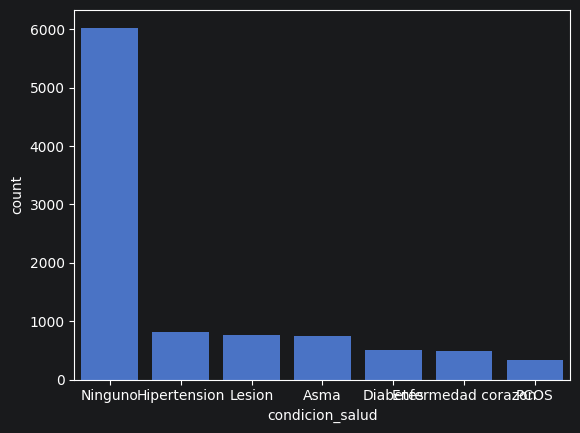


Columna: nivel_actividad
nivel_actividad
Moderado    3594
Bajo        3326
Alto        2778
Name: count, dtype: int64


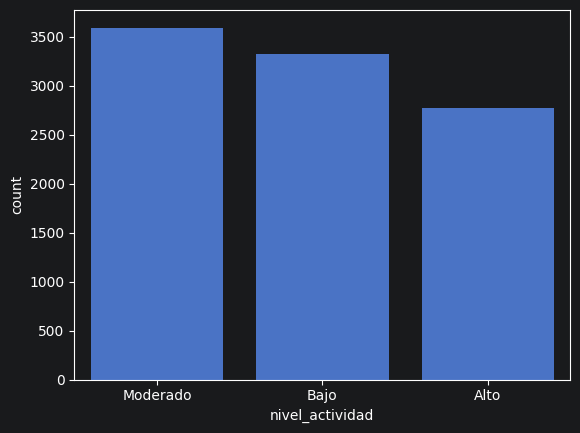


Columna: nivel_experiencia
nivel_experiencia
Intermedio      4100
Principiante    3608
Avanzado        1990
Name: count, dtype: int64


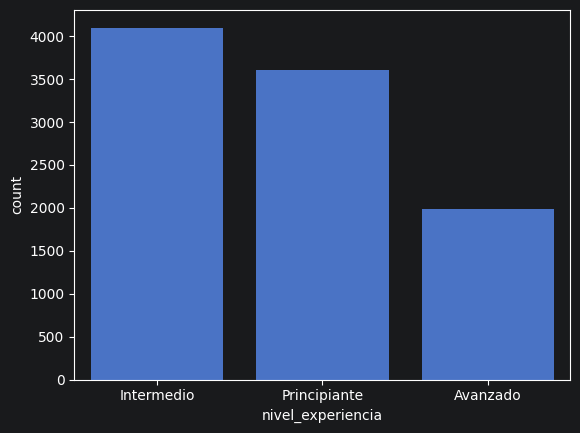


Columna: dieta_preferida
dieta_preferida
No-Vegetariano    2456
Vegano            2426
Pescetariano      2403
Vegetariano       2402
Animal              11
Name: count, dtype: int64


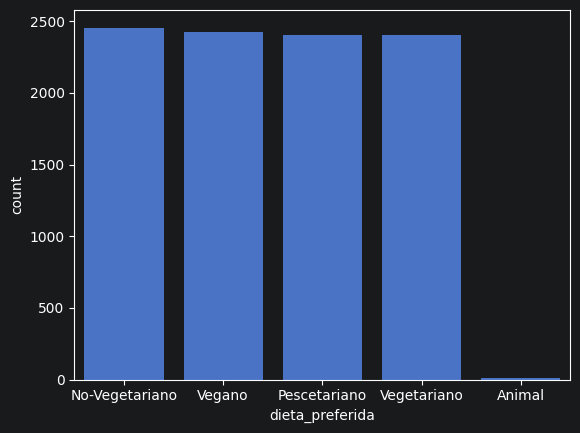


Columna: entrenamiento_preferido
entrenamiento_preferido
Funcional       1666
Hit             1620
Flexibilidad    1618
Cardio          1602
Fuerza          1601
Balance         1591
Name: count, dtype: int64


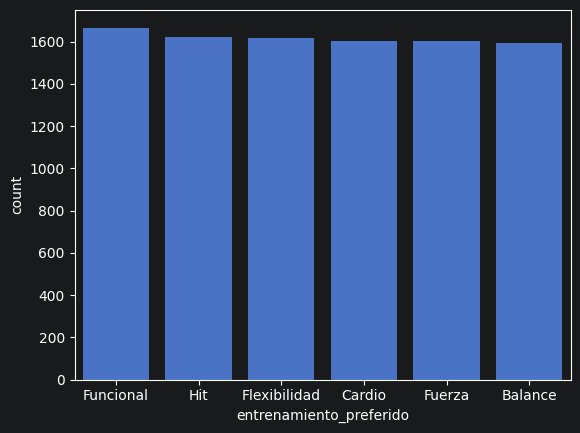


Columna: plan_entrenamiento
plan_entrenamiento
Ninguno    3807
Medio      2945
Bajo       2290
Alto        656
Name: count, dtype: int64


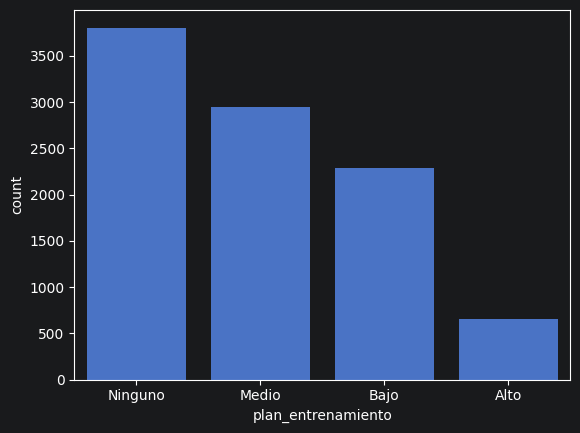


Columna: plan_nutricion
plan_nutricion
Balanceado       4297
Sin plan         2522
Basico           2287
Especializado     592
Name: count, dtype: int64


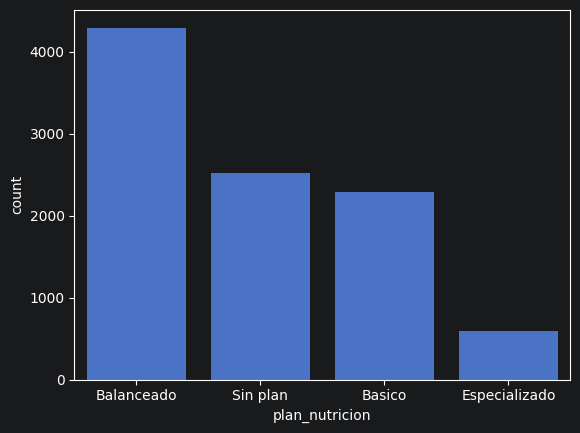


Columna: genero
genero
Femenino     4719
Masculino    4611
Otro          368
Name: count, dtype: int64


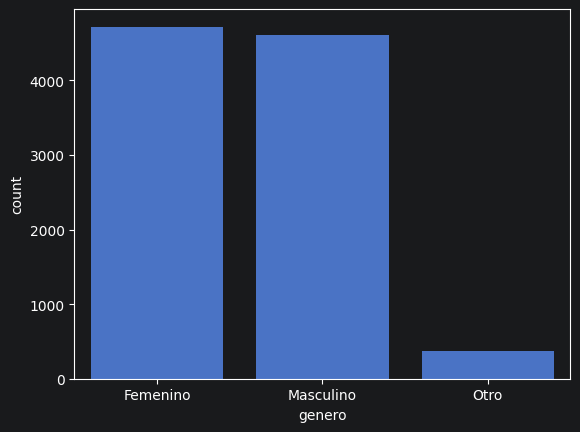

In [463]:
# Descripción de variables categóricas
for c in categorical_cols:
    print(f"\nColumna: {c}")
    print(df[c].value_counts())
    sns.countplot(data=df, x=c, order=df[c].value_counts().index)
    plt.show()

Todos los valores de las variables categóricas son sensatos, exceptuando 2 escenarios.

1. `objetivo`: hay 4 valores de "grasa". Esto se puede atribuir a un error de tipeo, se puede corregir a "Perdida grasa" para mantener la consistencia con los otros valores de esa columna.
2. `dieta_preferida`: hay tan solo 11 valores de "Animal". Estos podrían potencialmente ser considerados outliers, a pesar de ser válidos. Se podría considerar eliminar estos registros para evitar que afecten el análisis posterior, aunque también se podría mantener esta información si se considera relevante para el estudio.

# Limpieza de datos

In [464]:
# Copiar el df para la limpieza
clean_df = df.copy()
clean_df.shape

(9698, 26)

### Horas de sueño

In [465]:
# Verificar horas de sueño

print(f"Cantidad de registros con 0 horas de sueño: {len(clean_df[clean_df['horas_sueno'] == 0])}")

print(f"Cantidad de registros con 23 horas de sueño: {len(clean_df[clean_df['horas_sueno'] == 23])}")

print(f"Cantidad de registros con menos de 4 horas de sueño: {len(clean_df[clean_df['horas_sueno'] <= 4])}")

print(f"Cantidad de registros con más de 14 horas de sueño: {len(clean_df[clean_df['horas_sueno'] >= 14])}")

# Eliminar registros con 0 horas de sueño
clean_df = clean_df[clean_df['horas_sueno'] != 0]
clean_df = clean_df[clean_df['horas_sueno'] != 23]

print(f"Cantidad de registros después de eliminar casos extremos en horas de sueño: {len(clean_df)}")

Cantidad de registros con 0 horas de sueño: 1
Cantidad de registros con 23 horas de sueño: 1
Cantidad de registros con menos de 4 horas de sueño: 1
Cantidad de registros con más de 14 horas de sueño: 2
Cantidad de registros después de eliminar casos extremos en horas de sueño: 9696


In [466]:
# Verificar resultados
clean_df['horas_sueno'].describe()

count    9696.000000
mean        7.003455
std         1.438714
min         4.500000
25%         5.800000
50%         7.000000
75%         8.200000
max        15.000000
Name: horas_sueno, dtype: float64

En general, los nuevos datos parecen tener valores coherentes. Hay una persona con 15 horas de sueño, lo cual es alto pero no del todo imposible, por lo que se decidió mantener este registro. Sin embargo, se eliminaron los registros con 0 horas de sueño y 23 horas de sueño, ya que estos valores son poco probables y podrían ser errores de registro o casos extremos que podrían afectar el análisis posterior.

### Variables binarias representadas como numéricas

In [467]:
# Convertir variables binarias a categóricas

def transform_binary(t_df: pd.DataFrame) -> pd.DataFrame:
    t_df = t_df.copy()
    binary_cols = ['tiene_alergia', 'problemas_digestivos', 'fumador', 'alcohol']
    for c in binary_cols:
        t_df[c] = t_df[c].map({0: 'No', 1: 'Si'})
    return t_df


ft_binary_cleaner = FunctionTransformer(transform_binary, validate=False)

In [468]:
# Aplicar la transformación
clean_df = ft_binary_cleaner.transform(clean_df)
clean_df.head()

,edad,peso,altura,bmi,objetivo,condicion_salud,nivel_actividad,nivel_experiencia,dieta_preferida,horas_sueno,...,cigarrillos_dia,alcohol,alcohol_semana,score_micronutrientes,ingesta_proteinas,pasos_dia,ingesta_agua,plan_entrenamiento,plan_nutricion,genero
0,60,73.7,1.61,28.43,Resistencia,Hipertension,Bajo,Avanzado,Vegano,5.5,...,0.0,No,0.0,0.92,182.1,16485,2.49,Medio,Sin plan,Masculino
1,17,121.0,1.97,31.18,Resistencia,Enfermedad corazon,Moderado,Principiante,Vegetariano,6.9,...,0.0,No,0.0,0.76,167.7,14256,2.04,Ninguno,Sin plan,Femenino
2,43,110.0,1.52,47.61,General,Ninguno,Bajo,Principiante,No-Vegetariano,6.0,...,0.0,No,0.0,0.34,104.9,3050,2.53,Bajo,Basico,Masculino
3,49,73.6,1.96,19.16,General,Ninguno,Moderado,Principiante,No-Vegetariano,5.7,...,0.0,No,0.0,0.71,59.5,2264,3.36,Ninguno,Sin plan,Otro
4,53,80.8,1.76,26.08,Resistencia,Hipertension,Alto,Principiante,Pescetariano,5.8,...,8.7,No,0.0,0.98,51.1,12774,1.90,Medio,Sin plan,Femenino


### Verificar BMI

In [469]:
# Verificar consistencia de BMI

def calc_bmi(weight_series: pd.Series, height_series: pd.Series) -> pd.Series:
    bmi = weight_series / (height_series ** 2)
    return bmi


t_df = clean_df.copy()
calculated_bmi = round(calc_bmi(t_df['peso'], t_df['altura']), 2)
bmi_diff = np.abs(calculated_bmi - t_df['bmi'])
inconsistent_bmi = t_df[bmi_diff > 1]  # Considerar inconsistencias mayores a 1 punto de BMI
print(f"Cantidad de registros con BMI inconsistente: {len(inconsistent_bmi)}")

Cantidad de registros con BMI inconsistente: 0


No se encontraron inconsistencias significativas en el BMI

### Consistencia en Objetivo

In [470]:
# Corregir typo en objetivo
t_df = clean_df.copy()

t_df['objetivo'] = t_df['objetivo'].map({'grasa': 'Perdida grasa',
                                         'Perdida grasa': 'Perdida grasa',
                                         'Ganancia muscular': 'Ganancia muscular',
                                         'General': 'General',
                                         'Resistencia': 'Resistencia', })

t_df['objetivo'].describe()

count                  9696
unique                    4
top       Ganancia muscular
freq                   2755
Name: objetivo, dtype: object

In [471]:
t_df['objetivo'].value_counts()

objetivo
Ganancia muscular    2755
Perdida grasa        2598
General              2220
Resistencia          2123
Name: count, dtype: int64

In [472]:
clean_df = t_df.copy()

### Dieta preferida

In [473]:
# Mappear registros de Animal a No-vegetariano

t_df = clean_df.copy()

t_df['dieta_preferida'].value_counts()

dieta_preferida
No-Vegetariano    2455
Vegano            2426
Vegetariano       2402
Pescetariano      2402
Animal              11
Name: count, dtype: int64

In [474]:
# Mappeo

t_df['dieta_preferida'] = t_df['dieta_preferida'].map({'Animal': 'No-Vegetariano',
                                                       'Vegano': 'Vegano',
                                                       'Vegetariano': 'Vegetariano',
                                                       'Pescetariano': 'Pescetariano',
                                                       'No-Vegetariano': 'No-Vegetariano'})

t_df['dieta_preferida'].value_counts()

dieta_preferida
No-Vegetariano    2466
Vegano            2426
Vegetariano       2402
Pescetariano      2402
Name: count, dtype: int64

In [475]:
clean_df = t_df.copy()

### Cigarrillos al día sin decimales

In [476]:
# Redondear cigarrillos al día a enteros
t_df = clean_df.copy()
t_df['cigarrillos_dia'] = t_df['cigarrillos_dia'].round(0).astype(int)
t_df['cigarrillos_dia'].describe()

count    9696.000000
mean        2.174092
std         4.633378
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        18.000000
Name: cigarrillos_dia, dtype: float64

## Preparación previa al modelado

In [477]:
# Dataframe final para los modelos
final_df = clean_df.copy()

final_df.head()

,edad,peso,altura,bmi,objetivo,condicion_salud,nivel_actividad,nivel_experiencia,dieta_preferida,horas_sueno,...,cigarrillos_dia,alcohol,alcohol_semana,score_micronutrientes,ingesta_proteinas,pasos_dia,ingesta_agua,plan_entrenamiento,plan_nutricion,genero
0,60,73.7,1.61,28.43,Resistencia,Hipertension,Bajo,Avanzado,Vegano,5.5,...,0.0,No,0.0,0.92,182.1,16485,2.49,Medio,Sin plan,Masculino
1,17,121.0,1.97,31.18,Resistencia,Enfermedad corazon,Moderado,Principiante,Vegetariano,6.9,...,0.0,No,0.0,0.76,167.7,14256,2.04,Ninguno,Sin plan,Femenino
2,43,110.0,1.52,47.61,General,Ninguno,Bajo,Principiante,No-Vegetariano,6.0,...,0.0,No,0.0,0.34,104.9,3050,2.53,Bajo,Basico,Masculino
3,49,73.6,1.96,19.16,General,Ninguno,Moderado,Principiante,No-Vegetariano,5.7,...,0.0,No,0.0,0.71,59.5,2264,3.36,Ninguno,Sin plan,Otro
4,53,80.8,1.76,26.08,Resistencia,Hipertension,Alto,Principiante,Pescetariano,5.8,...,8.7,No,0.0,0.98,51.1,12774,1.90,Medio,Sin plan,Femenino


In [478]:
# Dividir el dataset en X & y
X = final_df.drop(columns=[VOE, VON])
y_e = final_df[VOE]
y_n = final_df[VON]

In [479]:
# Dividir el dataset en train y test
X_train, X_test, y_train_e, y_test_e, y_train_n, y_test_n = train_test_split(X, y_e, y_n, test_size=0.2,
                                                                             random_state=42)

# Modelos de regresión logística

In [480]:
# Diccionario de modelos de regresión logística

"""
Estructura propuesta:

{
  [model_name]: {
    "cv": GridSearchCV,      // El gridsearch completo para extraer info
    "cv_rmse": Object,       // -cross_val_score(pipeline, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
    "best_y_pred": int,      // La predicción del modelo con mejores hiperparámetros
  }
}
"""

r_models = {}

## Modelo 1: Regresión sobre el objetivo de entrenamiento

In [481]:
# TODO: e_regression

## Modelo 2: Regresión sobre el objetivo de nutrición

In [482]:
# TODO: n_regression

## Modelos de clasificación por árboles de decisión:

In [483]:
# Diccionario de modelos de clasificación por árboles de decisión

"""
Estructura propuesta:

{
  [model_name]: {
    "cv": GridSearchCV,      // El gridsearch completo para extraer info
    "best_y_pred": int,      // La predicción del modelo con mejores hiperparámetros
  }
}
"""

c_models = {}

## Modelo 3: Clasificación sobre el objetivo de entrenamiento

In [484]:
# TODO: e_classification

## Modelo 4: Clasificación sobre el objetivo de nutrición

In [485]:
# TODO: n_classification

# Comparación de modelos

## Comparación de modelos de regresión

In [486]:
regression_models_summary = {
    'Modelo': [],
    'RMSE Test': [],
    'MAE Test': [],
    'R2 Test': [],
    'Mean CV RMSE': [],
    'Std CV RMSE': [],
    'Params': [],
}

if r_models != {}:
    for model_name, model_info in r_models.items():

        model = r_models[model_name]
        cv = model['cv']
        cv_rmse = model['cv_rmse']
        y_pred = model['best_y_pred']

        # Extraer las métricas de interés para comparar todos los modelos propuestos
        regression_models_summary['Modelo'].append(model_name)

        if model_name.startswith('e'):
            regression_models_summary['RMSE Test'].append(np.sqrt(mean_squared_error(y_test_e, y_pred)))
            regression_models_summary['MAE Test'].append(mean_absolute_error(y_test_e, y_pred))
            regression_models_summary['R2 Test'].append(r2_score(y_test_e, y_pred))
            regression_models_summary['Mean CV RMSE'].append(cv_rmse.mean())
            regression_models_summary['Std CV RMSE'].append(cv_rmse.std())
            regression_models_summary['Params'].append(cv.best_params_)
        elif model_name.startswith('n'):
            regression_models_summary['RMSE Test'].append(np.sqrt(mean_squared_error(y_test_n, y_pred)))
            regression_models_summary['MAE Test'].append(mean_absolute_error(y_test_n, y_pred))
            regression_models_summary['R2 Test'].append(r2_score(y_test_n, y_pred))
            regression_models_summary['Mean CV RMSE'].append(cv_rmse.mean())
            regression_models_summary['Std CV RMSE'].append(cv_rmse.std())
            regression_models_summary['Params'].append(cv.best_params_)

summary_df = pd.DataFrame(regression_models_summary).round(4)
print(summary_df.to_string(index=False))

Empty DataFrame
Columns: [Modelo, RMSE Test, MAE Test, R2 Test, Mean CV RMSE, Std CV RMSE, Params]
Index: []


# Comparación de modelos de clasificación

In [487]:
classification_models_summary = {
    'Modelo': [],
    'Precision Test': [],
    'Recall Test': [],
    'F1 Test': [],
    'Accuracy Test': [],
    'Mean Test Score': [],
    'Std Test Score': [],
    'Params': []
}

if c_models != {}:
    for model_name, model_info in c_models.items():

        model = c_models[model_name]
        cv = model['cv']
        y_pred = model['best_y_pred']

        # Extraer las métricas de interés para comparar todos los modelos propuestos

        classification_models_summary['Modelo'].append(model_name)

        if model_name.startswith('e'):
            classification_models_summary['Precision Test'].append(precision_score(y_test_e, y_pred))
            classification_models_summary['Recall Test'].append(recall_score(y_test_e, y_pred))
            classification_models_summary['F1 Test'].append(f1_score(y_test_e, y_pred))
            classification_models_summary['Accuracy Test'].append(accuracy_score(y_test_e, y_pred))
            classification_models_summary['Mean Test Score'].append(cv.best_score_)
            classification_models_summary['Std Test Score'].append(cv.cv_results_['std_test_score'][cv.best_index_])
            classification_models_summary['Params'].append(cv.best_params_)
        elif model_name.startswith('n'):
            classification_models_summary['Precision Test'].append(precision_score(y_test_n, y_pred))
            classification_models_summary['Recall Test'].append(recall_score(y_test_n, y_pred))
            classification_models_summary['F1 Test'].append(f1_score(y_test_n, y_pred))
            classification_models_summary['Accuracy Test'].append(accuracy_score(y_test_n, y_pred))
            classification_models_summary['Mean Test Score'].append(cv.best_score_)
            classification_models_summary['Std Test Score'].append(cv.cv_results_['std_test_score'][cv.best_index_])
            classification_models_summary['Params'].append(cv.best_params_)

summary_df = pd.DataFrame(classification_models_summary).round(4)
print(summary_df.to_string(index=False))

Empty DataFrame
Columns: [Modelo, Precision Test, Recall Test, F1 Test, Accuracy Test, Mean Test Score, Std Test Score, Params]
Index: []


## Selección del mejor modelo

# Predicción en el conjunto de test